# NetworkX: Graph Theory

## 1. Basics
A graph models objects and the connections between them (like people and friendships, or cities and roads). This makes it useful for studying how things are linked, finding routes, and spotting important nodes or groups in a network.

### 1.1. Definition
A graph is written as $G=(V,E)$, where $V$ is the set of vertices/nodes and $E$ is the set of edges/links. In Python, NetworkX is a common library for creating and analyzing graphs. You can create graph using an edge list, a neighbor list or an adjacency matrix.

|Format|[From Python object]|[From file]|
|:-|:-|:-|
|Edge list|`nx.from_edgelist()`|`nx.read_edgelist()`|
|Neighbor list|`nx.from_dict_of_lists()`|`nx.read_adjlist()`|
|Adjacency matrix|`nx.from_numpy_matrix()`||

[From Python object]: https://networkx.org/documentation/stable/reference/convert.html
[From file]: https://networkx.org/documentation/stable/reference/readwrite/index.html

In [1]:
import sys; sys.path.append('..')
from mlkit import np, pd, nx, plt, sns

In [73]:
edges = [(1,2), (2,3), (3,4), (4,5)]
ge = nx.from_edgelist(edges)

In [74]:
neighbors = {
    'A': ['B', 'D'],
    'B': ['A', 'C'],
    'C': ['B'],
    'D': ['A']
}

gn = nx.from_dict_of_lists(neighbors)

In [75]:
adj_matrix = np.array([
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
])

gm = nx.from_numpy_array(adj_matrix)

:::{admonition} Pitfall
:class: danger

NetworkX allows you to draw graphs, but layouts can trick your eyes: nodes might look close just because the drawing algorithm placed them that way. Always support a picture with numbers (degree, components, distances), not just the drawing.

:::

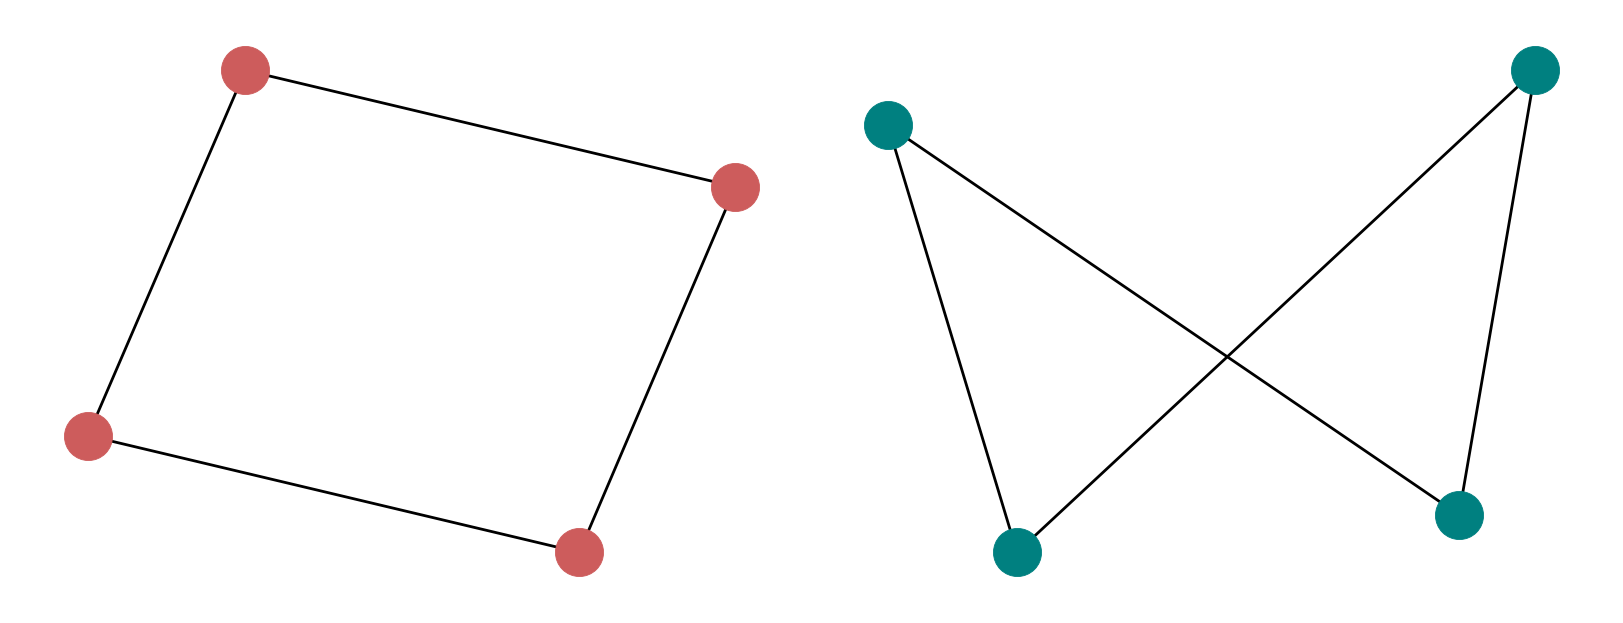

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
nx.draw(gm, ax=ax[0], pos=nx.spring_layout(gm, seed=0), node_color='dimgrey')
nx.draw(gm, ax=ax[1], pos=nx.spring_layout(gm, seed=10), node_color='dimgrey')
plt.show()

### 1.2. Key vocabulary
- Adjacent: Two nodes are adjacent if there is an edge between them. They are also called neighbors.
- Degree: The degree of a node is how many edges touch it.
- Path: A path is a sequence of nodes connected by edges, like A-B-C.
- Cycle: A cycle is a path that starts and ends at the same node, like A-B-C-A.
- Connected graph: An undirected graph is connected if every node can reach every other node through some path. If not, it has connected components (separate *islands*).

### 1.3. Types of graphs
- Directed graph: edges have direction, for example: social networks follows.
- Weighted graph: edges have weights, for example: distances between cities.
- Bipartite graph: nodes can be divided into two sets, and edges only connect nodes from different sets, for example: users and the movies they rate.
- Tree: a special graph with no cycles, for example: family trees.

In [77]:
dg = nx.DiGraph()
dg.add_edge('A', 'B')

In [78]:
wg = nx.Graph()
wg.add_edge('A', 'B', weight=5)
wg.add_edge('B', 'C', weight=2)

In [79]:
students = ['S1', 'S2']
classes = ['Math', 'History']

bg = nx.Graph()
bg.add_nodes_from(students, bipartite=0)
bg.add_nodes_from(classes, bipartite=1)
bg.add_edges_from([('S1', 'Math'), ('S2', 'Math'), ('S2', 'History')])

### 1.4. Statistics
- Size: $|V|$ nodes, $|E|$ edges
- Density: how full the graph is (0 = sparse, 1 = complete)
- Degree summary: min/avg/max degree, top-degree nodes
- Connectivity: number of components, size of largest component

In [80]:
adj_matrix = np.array([
    [0, 1, 1, 1],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 0],
])

g = nx.from_numpy_array(adj_matrix)

In [81]:
# g.number_of_edges()
# g.number_of_nodes()
# nx.density(g)
nx.is_connected(g)

True

In [82]:
degrees = dict(g.degree())
max_degree = max(degrees.values())
avg_degree = sum(degrees.values()) / len(degrees)

In [83]:
# handshake lemma
sum(degrees.values()) == 2 * g.number_of_edges()

True

::::{admonition} Case
:class: tip

:::{image} ../image/chap_02/seven_bridges.png
:height: 400px
:align: center
:::

::::

## 2. Graph algorithms

### 2.1. Graph traversal
Traversal is a general strategy for exploring a graph: starting from a chosen node, you systematically visit reachable nodes (usually once each). Traversal isn't the answer by itself, it's a building block used inside many graph tasks like reachability, finding connected components, detecting cycles, or building shortest paths.

#### Depth-First Search
The idea of [Depth-First Search] (DFS) is to explore as deep as possible along each branch before backtracking. You can implement it using recursion or a [stack]. DFS is good for tasks like cycle detection and topological sorting. Here is how it works conceptually:
- Start at a chosen node, mark it as visited.
- Visit and unvisited neighbor.
- Keep going deeper until you hit a dead end.
- Backtrack to the last node with an unvisited neighbor and continue.

[Depth-First Search]: https://en.wikipedia.org/wiki/Depth-first_search
[stack]: https://en.wikipedia.org/wiki/Stack_(abstract_data_type)

#### Bereadth-First Search
The idea of [Breadth-First Search] (BFS) is to explore all neighbors at the present depth before moving on to nodes at the next depth level. You can implement it using a [queue]. BFS is great for finding the shortest path in unweighted graphs and for level-order traversal. Here is how it works conceptually:
- Start at a chosen node, mark it as visited, and enqueue it.
- Dequeue a node, visit all its unvisited neighbors, mark them as visited, and enqueue them.
- Repeat until the queue is empty.

[Breadth-First Search]: https://en.wikipedia.org/wiki/Breadth-first_search
[queue]: https://en.wikipedia.org/wiki/Queue_(abstract_data_type)

### 2.2. Shortest path
The shortest path problem asks how to find a route between two nodes in a graph that has the minimum total cost. The *cost* might be the number of edges (in an unweighted graph) or the sum of edge weights like distance, time or money (in a weighted graph). Depending on the graph and the rules, you might want (1) the shortest path from one source to one target, (2) from one source to all vertices, or (3) between every pair of vertices. Shortest path methods are widely used in navigation, network routing, and scheduling. Common algorithms include:
- [BFS] for unweighted graphs. Core idea: speard out one step at a time util you reach the target.
- [Dijkstra] for graphs with positive weights
- A*
- Bellman-Ford
- Floyd-Warhsall

[BFS]: https://en.wikipedia.org/wiki/Breadth-first_search
[Dijkstra]: https://en.wikipedia.org/wiki/Dijkstra%27s_algorithm

### 2.3. Euler path

### 2.4. Hamilton path
- Exact: DFS, Brute-force
- approximation: Christofide
- meta heuristic: Genetic, Simulated annealing
- Ant colony

### 2.5. Graph coloring
- Greedy
- Welsh-Powell
- DSATUR

- Sub-problems
- Methods and algorithms
- Applications

## 3. Network analysis

### 3.1. PageRank
[PageRank] was originally invented by Google in 1998 and had became an extraordinary success as a search engines. It makes clever use of the eigenvalues to rank hundreds of millions websites, which delivers the most relevant result for the search queries. In NetworkX, the algorithm is implemented via the function [`pagerank()`].

[PageRank]: https://en.wikipedia.org/wiki/PageRank
[`pagerank()`]: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html

In the next sections, we explore PageRank on a small system containing $N=6$ websites. We use a directed graph to encode this system, where each node is a website and each edge is a link from a website to another. Our target is to find a *scoring vector* $\mathbf{r}\in\mathbb{R}^N$, in which the score of any website, $r_n>0$, should be higher if:
- The website index $n$ has more backlinks
- Those backlinks are from websites with high scores

In [84]:
import sys; sys.path.append('..')
from mlkit import np, pd, nx, plt, sns

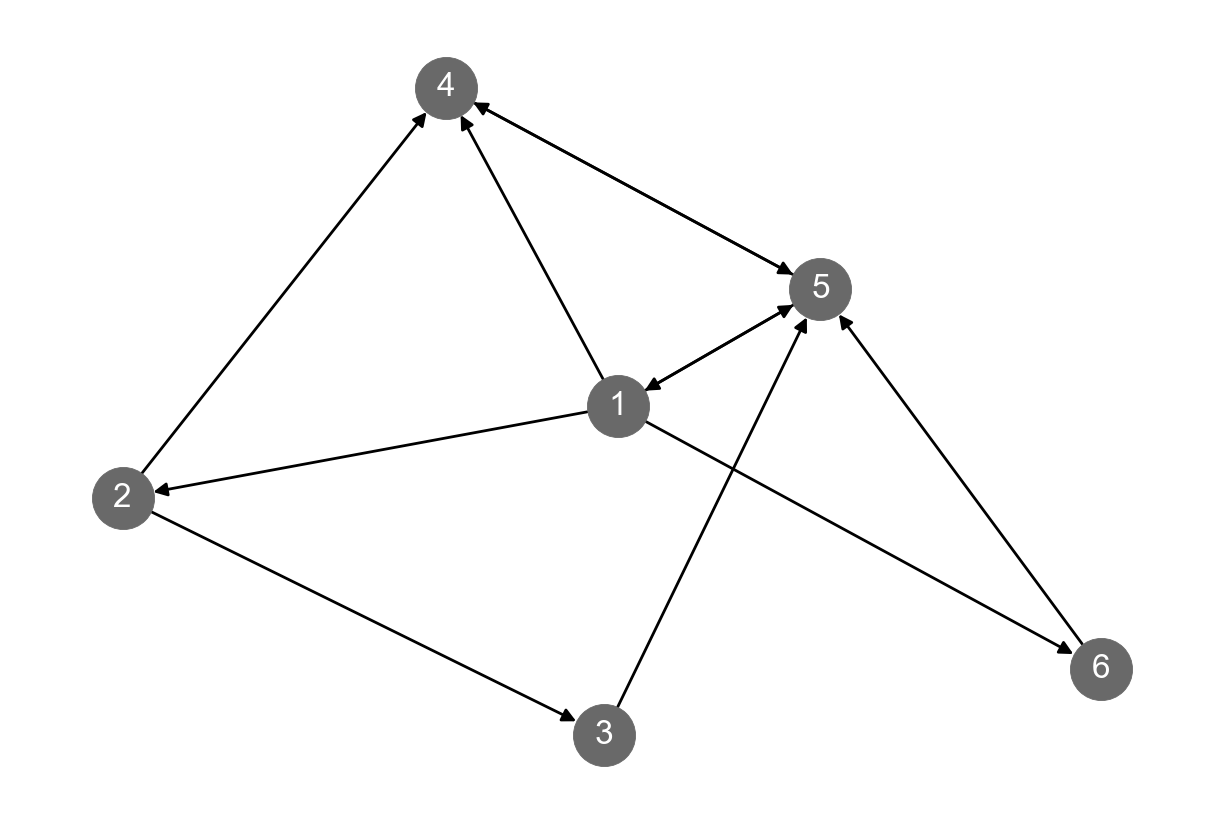

In [85]:
web_graph = nx.DiGraph()
web_graph.add_nodes_from([1, 2, 3, 4, 5, 6])
web_graph.add_edges_from([
    (1, 2), (1, 4), (1, 5), (1, 6),
    (2, 3), (2, 4),
    (3, 5),
    (4, 5),
    (5, 1), (5, 4),
    (6, 5)
])

fig, ax = plt.subplots(figsize=(6, 4))
pos = pos=nx.spring_layout(web_graph, seed=19)
nx.draw(web_graph, node_color='dimgrey', font_color='w', with_labels=True, node_size=500, pos=pos, ax=ax)

#### Eigenvalue centrality

:::{admonition} Case
:class: tip

The website P4 has three backlinks from pages P1, P2 and P5. We construct an equation represents how scores are transferred through the backlinks:

$$r_4=r_1+r_2+r_5$$

However, the pages P1, P2 and P5 transfer their points to other pages as well. In this case, P1 has $\ell_1=4$ forward links, P2 and P5 have $\ell_2=\ell_5=2$ forward links. The *transition equation* is written as:

$$r_4=\frac{r_1}{\ell_1}+\frac{r_2}{\ell_2}+\frac{r_5}{\ell_5}$$

:::

In general, all pages keep giving and recieving scores continuously. Instead of observing each page standalone, we write the whole *transition equation* using matrix notation:

$$\mathbf{Ar}=\mathbf{r}$$

Here, $\mathbf{A}$ is the *transition matrix*. Each column of $\mathbf{A}$ is a [probability vector] showing how a page distributes its score. This makes $\mathbf{A}$ a [stochastic matrix], which has $\lambda=1$ the dominant eigenvalue (under [Perron-Frobenius theorem]). By injecting $\lambda$ to the transition equation, $\mathbf{r}$ becomes the dominant eigenvector of $\mathbf{A}$.

[probability vector]: https://en.wikipedia.org/wiki/Probability_vector
[stochastic matrix]: https://en.wikipedia.org/wiki/Stochastic_matrix
[Perron-Frobenius theorem]: https://en.wikipedia.org/wiki/Perron%E2%80%93Frobenius_theorem

In [86]:
def get_transition_matrix(graph):
    adj_matrix = nx.adjacency_matrix(graph).todense().T
    out_degree = adj_matrix.sum(axis=0)
    share_weight = np.divide(1, out_degree, where=out_degree!=0)
    transition_matrix = np.multiply(adj_matrix, share_weight)
    return transition_matrix

transition_matrix = get_transition_matrix(web_graph)
print(transition_matrix)

[[0.   0.   0.   0.   0.5  0.  ]
 [0.25 0.   0.   0.   0.   0.  ]
 [0.   0.5  0.   0.   0.   0.  ]
 [0.25 0.5  0.   0.   0.5  0.  ]
 [0.25 0.   1.   1.   0.   1.  ]
 [0.25 0.   0.   0.   0.   0.  ]]


In [87]:
def get_dominant_eigenvector(transition_matrix):
    eigenvalues, eigenvectors = np.linalg.eig(transition_matrix)
    dominant_idx = np.argmax(np.real(eigenvalues))
    dominant_eigenvector = np.real(eigenvectors[:, dominant_idx])
    dominant_eigenvector = dominant_eigenvector / np.sum(dominant_eigenvector)
    return dominant_eigenvector

pagerank_vector = get_dominant_eigenvector(transition_matrix)
pagerank_vector

array([0.2  , 0.05 , 0.025, 0.275, 0.4  , 0.05 ])

:::{note}
There are other types of [centrality] beside eigenvalue centrality:
- Degree centrality is the degree of the node.
- Closeness centrality is the average length of the shortest path between the node and all other nodes.
- Betweeness centrality is the number of time a node acts as a bridge along the shortest path between two other nodes. 
:::

[centrality]: https://en.wikipedia.org/wiki/Centrality

#### Damping factor
With the introduction of the *damping factor* $\alpha$, PageRank assumes that internet users randomly teleport to pages other than forward links at the probability of $1-\alpha$. The dampen transition equation is given by:

$$
\begin{aligned}
\mathbf{r}
&= \alpha \mathbf{A}\mathbf{r} + (1 - \alpha)\mathbf{p} \\
&= \left( \alpha \mathbf{A} + (1 - \alpha)\mathbf{p1}^\top \right) \mathbf{r} \\
&= \mathbf{A}'\mathbf{r}
\end{aligned}
$$

Where:
- $\mathbf{p}=\mathbf{1}/n$ is the teleport vector
- $\mathbf{A}'=\alpha\mathbf{A}+(1-\alpha)\mathbf{p1}^\top$ is the dampen transition matrix

As $\mathbf{A}'$ is still a stochastic matrix, processing damping factor only requires updating the transition matrix without changing other calculations.

In [88]:
def get_transition_matrix(graph, alpha=0.85):
    adj_matrix = nx.adjacency_matrix(graph).todense().T
    out_degree = adj_matrix.sum(axis=0)
    share_weight = np.divide(1, out_degree, where=out_degree!=0)
    transition_matrix = np.multiply(adj_matrix, share_weight)

    n = transition_matrix.shape[0]
    transition_matrix *= alpha
    transition_matrix += (1 - alpha) * np.ones((n, n)) / n
    return transition_matrix

dampen_transition_matrix = get_transition_matrix(web_graph)
print(dampen_transition_matrix)

[[0.025  0.025  0.025  0.025  0.45   0.025 ]
 [0.2375 0.025  0.025  0.025  0.025  0.025 ]
 [0.025  0.45   0.025  0.025  0.025  0.025 ]
 [0.2375 0.45   0.025  0.025  0.45   0.025 ]
 [0.2375 0.025  0.875  0.875  0.025  0.875 ]
 [0.2375 0.025  0.025  0.025  0.025  0.025 ]]


#### Power iteration
In real life, there are billions of websites it's not possible to calculate the dominant eigenvector algebraically. Accordingly, a method for estimating the dominant eigenvector called the [power iteration] is used. This method initializes $\mathbf{r_0}$ arbitrary, then keep multiplying the matrix $\mathbf{A}$ to get $\mathbf{r}$:

$$\mathbf{r}=\lim_{p\rightarrow\infty}\mathbf{A}^p\,\mathbf{r_0}$$

Many implementations have pointed out that the convergence happens very fast, taking only about 100 iterations in case of millions of pages

[power iteration]: https://en.wikipedia.org/wiki/Power_iteration

In [89]:
def power_iteration(transition_matrix, max_iter=100, tol=1e-6):
    n = transition_matrix.shape[0]
    init_vector = np.ones(n) / n
    pagerank_vector = init_vector
    for _ in range(max_iter):
        next_vector = transition_matrix @ pagerank_vector
        error_vector = next_vector - pagerank_vector
        if np.linalg.norm(error_vector, 1) < tol:
            break
        pagerank_vector = next_vector
    return pagerank_vector

In [ ]:
power_iteration(transition_matrix)

array([0.2  , 0.05 , 0.025, 0.275, 0.4  , 0.05 ])

In [ ]:
# try with less iterations
power_iteration(transition_matrix, max_iter=10)

array([0.2025, 0.0492, 0.0256, 0.2772, 0.3964, 0.0492])

In [105]:
# try with damping factor
pagerank_vector = power_iteration(dampen_transition_matrix)
pagerank_vector

array([0.1861, 0.0646, 0.0524, 0.2531, 0.3792, 0.0646])

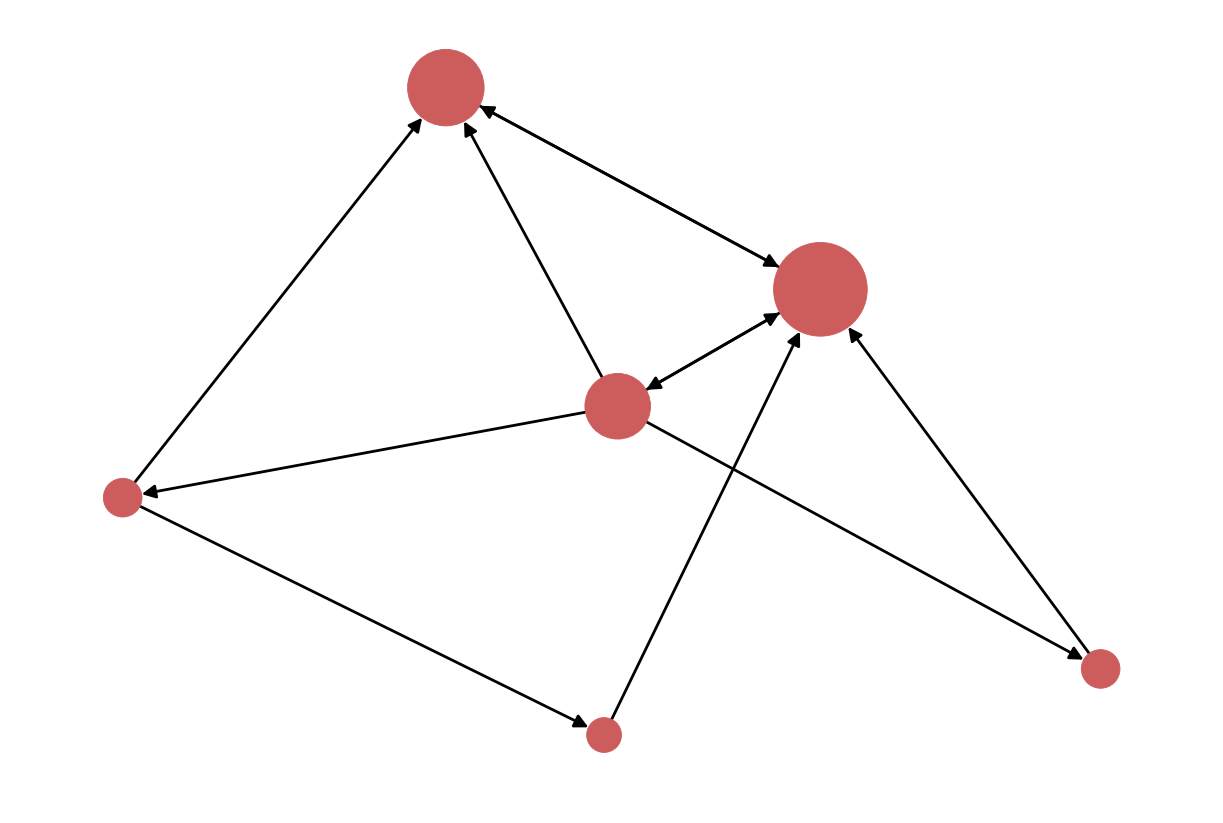

In [106]:
fig, ax = plt.subplots(figsize=(6, 4))
pos = pos=nx.spring_layout(web_graph, seed=19)
nx.draw(
    web_graph,
    node_color='indianred',
    node_size=pagerank_vector * 500 * web_graph.number_of_nodes(),
    pos=pos,
    ax=ax,
)

### 3.2. Graph clustering

### 3.3. Community detection

## Resources
- googleapis.com - [Method for node ranking in a linked database](https://patentimages.storage.googleapis.com/37/a9/18/d7c46ea42c4b05/US6285999.pdf)
- googleapis.com - [Producing a ranking for pages using distances in a web-link graph](https://patentimages.storage.googleapis.com/b8/dc/3e/3b5b32f8acd264/US9165040.pdf)
- trenton3983.github.io - [Introduction to Network Analysis in Python](https://trenton3983.github.io/files/projects/2020-05-21_intro_to_network_analysis_in_python/2020-05-21_intro_to_network_analysis_in_python.html)